# JEPA Pretraining Analysis (All-Asset Run)

This notebook focuses on the **shared JEPA pretraining stage** used before single-asset PPO runs.

It includes:
1. Model loading + architecture and parameter summary
2. Pretraining log visualization
3. Embedding analysis with PCA (2D + explained variance) and t-SNE (2D)
4. Extra diagnostics for embedding usefulness (collapse checks, probes, continuity)


In [6]:
from __future__ import annotations

import copy
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.manifold import TSNE
from sklearn.metrics import (
accuracy_score,
balanced_accuracy_score,
mean_squared_error,
r2_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



def find_project_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing src/ and configs/")


PROJECT_ROOT = find_project_root(Path.cwd())
print(f"Project root: {PROJECT_ROOT}")

import sys
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from Datasets.multi_asset_dataset import Dataset_Finance_MultiAsset
from Training.callbacks import make_patches
from models.jepa.jepa import JEPA
from models.time_series.patchTransformer import PatchTSTEncoder

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Project root: C:\python\koulu\Gradu
Device: cuda


In [7]:
# -----------------------------
# User parameters
# -----------------------------
SINGLE_ASSET_RUN_CONFIG = "configs/single_asset_run.json"
RUN_NAME_OVERRIDE = None

JEPA_CONFIG_OVERRIDE = None
JEPA_CHECKPOINT_OVERRIDE = None
JEPA_LOG_CSV_OVERRIDE = None

# Optional: compare PCA against a JEPA checkpoint trained with asset-id embeddings
RUN_ASSET_IDS_PCA_COMPARISON = True
ASSET_IDS_COMPARISON_CHECKPOINT = "checkpoints/jepa_pretrain_all_asset_ids/best.pt"

EMBEDDING_SPLIT = "train"   # train | val | test
MAX_SAMPLES = 5000
BATCH_SIZE = 256

SHUFFLE_TRAIN_LOADER = True  # use shuffled train loader to avoid front-loading first asset

# Representation used for downstream analysis
# token_last: last context token embedding (recommended for JEPA-style token analysis)
# mean_pool: mean over context tokens
# flatten_tokens: flatten all context tokens [N,D] -> [N*D]
EMBEDDING_REPRESENTATION = "mean_pool"  # token_last | mean_pool | flatten_tokens

TSNE_MAX_POINTS = 2000
TSNE_PERPLEXITY = 30
N_PCA_COMPONENTS = 1000


In [8]:
def resolve_project_path(path_value: str | Path) -> Path:
    p = Path(path_value)
    return p if p.is_absolute() else (PROJECT_ROOT / p).resolve()


def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


single_cfg_path = resolve_project_path(SINGLE_ASSET_RUN_CONFIG)
single_cfg = load_json(single_cfg_path) if single_cfg_path.exists() else {}

run_name_from_cfg = single_cfg.get("output", {}).get("run_name")
run_name = RUN_NAME_OVERRIDE or run_name_from_cfg or "single_asset_run1"

if JEPA_CONFIG_OVERRIDE:
    jepa_cfg_path = resolve_project_path(JEPA_CONFIG_OVERRIDE)
elif single_cfg.get("jepa_config"):
    jepa_cfg_path = resolve_project_path(single_cfg["jepa_config"])
else:
    jepa_cfg_path = resolve_project_path("configs/jepa_pretrain_all.json")

jepa_cfg = load_json(jepa_cfg_path)

# Candidate checkpoint paths (priority order)
ckpt_candidates = []
if JEPA_CHECKPOINT_OVERRIDE:
    ckpt_candidates.append(resolve_project_path(JEPA_CHECKPOINT_OVERRIDE))

single_ckpt_root = resolve_project_path(
    single_cfg.get("output", {}).get("checkpoint_root", "checkpoints/single_asset")
)
ckpt_candidates.append(single_ckpt_root / run_name / f"{run_name}_jepa" / "best.pt")

jepa_paths = jepa_cfg.get("paths", {})
jepa_ckpt_root = resolve_project_path(jepa_paths.get("checkpoint_root", "checkpoints"))
ckpt_candidates.append(jepa_ckpt_root / jepa_cfg["model_name"] / "best.pt")

checkpoint_path = next((p for p in ckpt_candidates if p.exists()), ckpt_candidates[0])
asset_ids_compare_checkpoint_path = (
    resolve_project_path(ASSET_IDS_COMPARISON_CHECKPOINT)
    if ASSET_IDS_COMPARISON_CHECKPOINT
    else None
)

# Candidate log paths (priority order)
log_candidates = []
if JEPA_LOG_CSV_OVERRIDE:
    log_candidates.append(resolve_project_path(JEPA_LOG_CSV_OVERRIDE))

single_log_root = resolve_project_path(
    single_cfg.get("output", {}).get("log_root", "logs/single_asset")
)
log_candidates.append(single_log_root / run_name / f"{run_name}_jepa_train_log.csv")

jepa_log_root = resolve_project_path(jepa_paths.get("log_root", "logs"))
log_candidates.append(jepa_log_root / f"{jepa_cfg['model_name']}_train_log.csv")

log_csv_path = next((p for p in log_candidates if p.exists()), log_candidates[0])

print(f"single-asset run config: {single_cfg_path}")
print(f"run_name: {run_name}")
print(f"jepa config: {jepa_cfg_path}")
print(f"checkpoint selected: {checkpoint_path}")
print(f"asset-id comparison checkpoint: {asset_ids_compare_checkpoint_path}")
print(f"log csv selected: {log_csv_path}")


single-asset run config: C:\python\koulu\Gradu\configs\single_asset_run.json
run_name: single_asset_run1
jepa config: C:\python\koulu\Gradu\configs\jepa_pretrain_all.json
checkpoint selected: C:\python\koulu\Gradu\checkpoints\single_asset\single_asset_run1\single_asset_run1_jepa\best.pt
log csv selected: C:\python\koulu\Gradu\logs\single_asset\single_asset_run1\single_asset_run1_jepa_train_log.csv


In [9]:
def parse_horizon_blocks(horizon_blocks: dict[str, list[int]]) -> tuple[dict[str, slice], int]:
    if not horizon_blocks:
        raise ValueError("horizon_blocks must be non-empty")

    parsed = []
    for name, bounds in horizon_blocks.items():
        if not isinstance(bounds, (list, tuple)) or len(bounds) != 2:
            raise ValueError(f"horizon_blocks[{name}] must be [start, end]")
        start, end = int(bounds[0]), int(bounds[1])
        if start < 1 or end < start:
            raise ValueError(f"Invalid horizon block {name}: [{start}, {end}]")
        parsed.append((name, start, end))

    parsed.sort(key=lambda x: x[1])
    if parsed[0][1] != 1:
        raise ValueError("horizon blocks must start at 1")

    prev_end = 0
    slices: dict[str, slice] = {}
    for name, start, end in parsed:
        if start != prev_end + 1:
            raise ValueError("horizon blocks must be contiguous")
        slices[name] = slice(start - 1, end)
        prev_end = end

    return slices, prev_end


def build_dataset_kwargs(cfg: dict) -> dict:
    d = cfg["dataset"]
    return {
        "root_path": d["root_path"],
        "data_path": d["data_path"],
        "start_date": d.get("start_date"),
        "size": int(d["context_len"]),
        "use_time_features": d.get("use_time_features", True),
        "rolling_window": d["rolling_window"],
        "train_split": d["train_split"],
        "test_split": d["test_split"],
        "regular_hours_only": d.get("regular_hours_only", True),
        "timeframe": d.get("timeframe", "15min"),
        "tickers": d.get("tickers"),
        "train_start_date": d.get("train_start_date"),
        "train_end_date": d.get("train_end_date"),
        "val_end_date": d.get("val_end_date"),
        "test_end_date": d.get("test_end_date"),
    }


model_cfg = jepa_cfg["jepa_model"]
patch_len = int(model_cfg["patch_len"])
patch_stride = int(model_cfg["patch_stride"])
context_len_steps = int(model_cfg.get("context_len_steps", jepa_cfg["dataset"]["context_len"]))
horizon_slices, horizon_tokens = parse_horizon_blocks(
    model_cfg.get(
        "horizon_blocks",
        {
            "near": [1, 1],
            "med": [2, 5],
            "far": [6, 17],
        },
    )
)
context_tokens = 1 + (context_len_steps - patch_len) // patch_stride
total_tokens = context_tokens + horizon_tokens
total_steps = (total_tokens - 1) * patch_stride + patch_len

print("JEPA token setup")
print(f"  context_len_steps={context_len_steps}")
print(f"  context_tokens={context_tokens}")
print(f"  horizon_tokens={horizon_tokens}")
print(f"  total_steps={total_steps}")


dataset_kwargs = build_dataset_kwargs(jepa_cfg)
# Resolve dataset paths relative to project root so notebook CWD does not matter
dataset_kwargs["root_path"] = str(resolve_project_path(dataset_kwargs["root_path"]))
data_path_obj = Path(dataset_kwargs["data_path"])
if data_path_obj.is_absolute():
    dataset_kwargs["data_path"] = str(data_path_obj)
else:
    dataset_kwargs["data_path"] = str(data_path_obj.as_posix())
dataset_kwargs["size"] = total_steps

train_ds = Dataset_Finance_MultiAsset(split="train", **dataset_kwargs)
val_ds = Dataset_Finance_MultiAsset(split="val", **dataset_kwargs)

aasset_universe = train_ds.asset_universe if getattr(train_ds, "asset_universe", None) else train_ds.asset_ids
asset_universe = list(aasset_universe)
idx_to_asset = {idx: asset for idx, asset in enumerate(asset_universe)}

print(f"train samples: {len(train_ds):,}")
print(f"val samples:   {len(val_ds):,}")
print(f"assets:        {len(asset_universe)}")
print(f"first assets:  {asset_universe[:10]}")


JEPA token setup
  context_len_steps=512
  context_tokens=64
  horizon_tokens=17
  total_steps=648
[Dataset_Finance_MultiAsset] Global date splits: mode=ratio train_start=2021-02-26 15:00:00+00:00 train_end=2024-08-01 15:15:00+00:00 val_end=2025-04-29 16:30:00+00:00 test_end=2026-01-23 21:00:00+00:00 n_dates=33179 n_train=23225 n_val=4978 n_test=4976
[Dataset_Finance_MultiAsset] Global date splits: mode=ratio train_start=2021-02-26 15:00:00+00:00 train_end=2024-08-01 15:15:00+00:00 val_end=2025-04-29 16:30:00+00:00 test_end=2026-01-23 21:00:00+00:00 n_dates=33179 n_train=23225 n_val=4978 n_test=4976
train samples: 741,127
val samples:   142,670
assets:        33
first assets:  ['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIA']


In [10]:
# Build JEPA architecture and load checkpoint
use_asset_embeddings = bool(model_cfg.get("use_asset_embeddings", True))
num_assets = len(asset_universe) if use_asset_embeddings else None

context_enc = PatchTSTEncoder(
    patch_len=patch_len,
    d_model=model_cfg["d_model"],
    n_features=model_cfg["n_features"],
    n_time_features=model_cfg["n_time_features"],
    nhead=model_cfg["nhead"],
    num_layers=model_cfg["num_layers"],
    dim_ff=model_cfg["dim_ff"],
    dropout=model_cfg.get("dropout", 0.0),
    num_assets=num_assets,
)

target_enc = copy.deepcopy(context_enc)

jepa_model = JEPA(
    context_enc,
    target_enc,
    d_model=model_cfg["d_model"],
    ema_tau_min=model_cfg["ema_tau_min"],
    ema_tau_max=model_cfg["ema_tau_max"],
    nhead=model_cfg["nhead"],
    dim_ff=model_cfg["dim_ff"],
    dropout=model_cfg.get("dropout", 0.0),
    predictor_num_layers=model_cfg.get("predictor_num_layers", 2),
    context_tokens=context_tokens,
    horizon_blocks=model_cfg.get("horizon_blocks"),
)

if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

ckpt = torch.load(checkpoint_path, map_location="cpu")
state_dict = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
missing, unexpected = jepa_model.load_state_dict(state_dict, strict=False)
jepa_model = jepa_model.to(DEVICE).eval()


def count_params(module: torch.nn.Module) -> tuple[int, int]:
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable


rows = []
for name, mod in [
    ("context_enc", jepa_model.context_enc),
    ("target_enc", jepa_model.target_enc),
    ("predictor", jepa_model.predictor),
    ("predictor_norm", jepa_model.predictor_norm),
]:
    total, trainable = count_params(mod)
    rows.append({"module": name, "params_total": total, "params_trainable": trainable})

rows.append(
    {
        "module": "target_queries",
        "params_total": int(jepa_model.target_queries.numel()),
        "params_trainable": int(jepa_model.target_queries.numel()),
    }
)

total_all, trainable_all = count_params(jepa_model)
rows.append({"module": "JEPA (full)", "params_total": total_all, "params_trainable": trainable_all})

param_df = pd.DataFrame(rows)
param_df["params_total_fmt"] = param_df["params_total"].map(lambda x: f"{x:,}")
param_df["params_trainable_fmt"] = param_df["params_trainable"].map(lambda x: f"{x:,}")

print("Checkpoint metadata")
if isinstance(ckpt, dict):
    for k in ["epoch", "global_step", "monitor", "asset_universe"]:
        if k in ckpt:
            print(f"  {k}: {ckpt[k]}")
print(f"Missing keys: {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")

print("\nModel config summary")
print(f"  d_model={model_cfg['d_model']} nhead={model_cfg['nhead']} layers={model_cfg['num_layers']} dim_ff={model_cfg['dim_ff']}")
print(f"  patch_len={patch_len} patch_stride={patch_stride} context_tokens={context_tokens} horizon_tokens={horizon_tokens}")
print(f"  use_asset_embeddings={use_asset_embeddings} num_assets={num_assets}")

param_df


c:\Users\ollik\miniconda3\envs\.graduenv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\ollik\AppData\Local\Temp\ipykernel_61196\3659811212.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `w

Checkpoint metadata
  epoch: 50
  global_step: 36924
  monitor: 0.04896425679326057
  asset_universe: ['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIA', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'QQQ', 'SHW', 'SPY', 'TRV', 'UNH', 'V', 'VZ', 'WMT']
Missing keys: 0
Unexpected keys: 0

Model config summary
  d_model=64 nhead=4 layers=4 dim_ff=256
  patch_len=8 patch_stride=8 context_tokens=64 horizon_tokens=17
  use_asset_embeddings=False num_assets=None


,module,params_total,params_trainable,params_total_fmt,params_trainable_fmt
0,context_enc,206849,206849,"206,849","206,849"
1,target_enc,206849,0,"206,849",0
2,predictor,133504,133504,"133,504","133,504"
3,predictor_norm,128,128,128,128
4,target_queries,1088,1088,"1,088","1,088"
5,JEPA (full),548418,341569,"548,418","341,569"


Loaded C:\python\koulu\Gradu\logs\single_asset\single_asset_run1\single_asset_run1_jepa_train_log.csv
Rows: 100
Columns: ['epoch', 'train_loss', 'val_loss', 'train_cosine_similarity', 'train_std_ctx', 'train_std_tgt', 'train_loss_near', 'train_loss_med', 'train_loss_far_pooled', 'train_loss_near_weighted', 'train_loss_med_weighted', 'train_loss_far_weighted', 'train_loss_total']


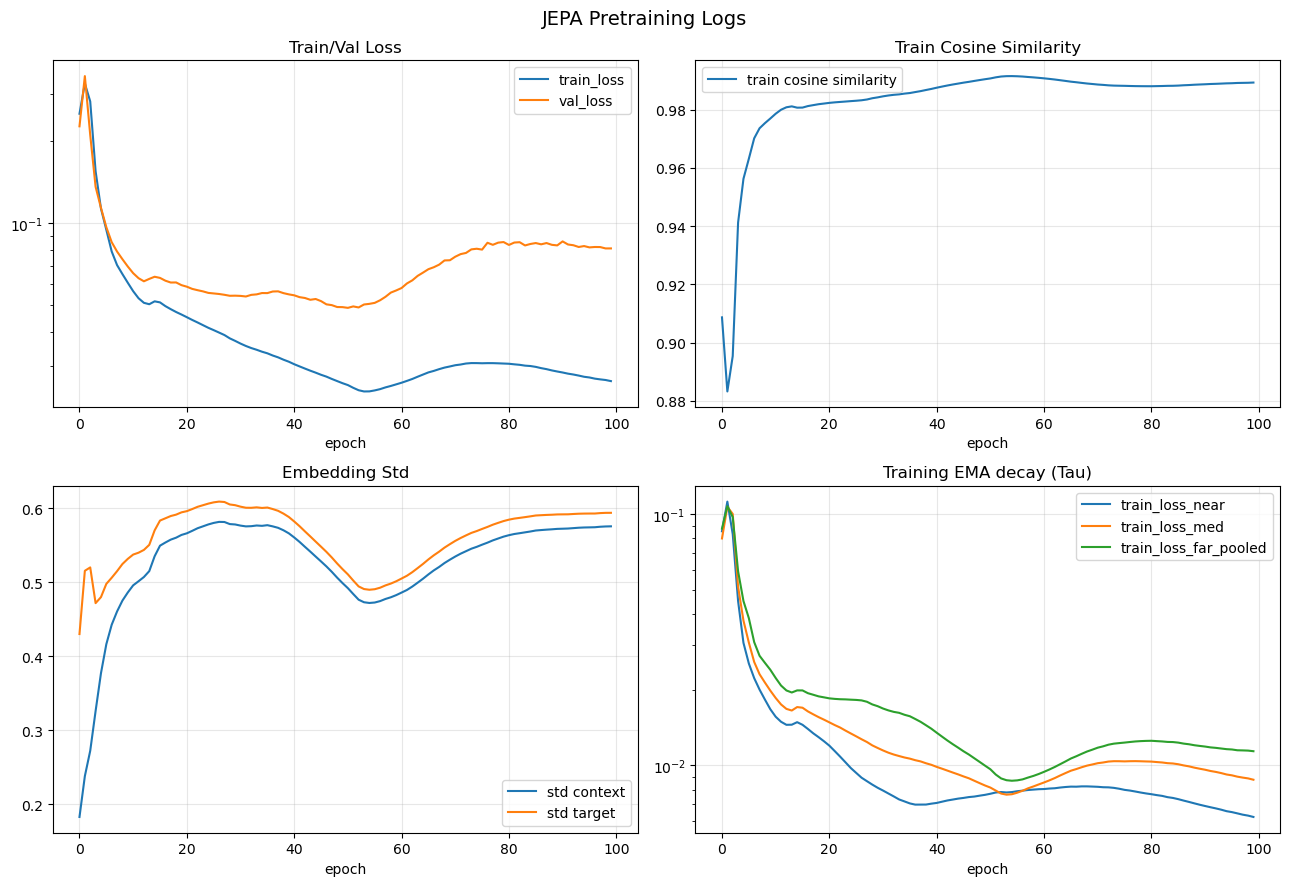

In [22]:
# Pretraining logs (2x2 figure)
if not log_csv_path.exists():
    raise FileNotFoundError(f"Log CSV not found: {log_csv_path}")

log_df = pd.read_csv(log_csv_path)
print(f"Loaded {log_csv_path}")
print(f"Rows: {len(log_df)}")
print(f"Columns: {list(log_df.columns)}")

x_col = "epoch" if "epoch" in log_df.columns else log_df.columns[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

# 1) train/val losses
if "train_loss" in log_df.columns:
    axes[0].plot(log_df[x_col], log_df["train_loss"], label="train_loss")
if "val_loss" in log_df.columns:
    axes[0].plot(log_df[x_col], log_df["val_loss"], label="val_loss")
axes[0].set_yscale("log")
axes[0].set_title("Train/Val Loss")
axes[0].set_xlabel(x_col)
axes[0].grid(True, alpha=0.3)
if axes[0].has_data():
    axes[0].legend()

# 2) cosine similarity
if "train_cosine_similarity" in log_df.columns:
    axes[1].plot(log_df[x_col], log_df["train_cosine_similarity"], label="train cosine similarity")
axes[1].set_title("Train Cosine Similarity")
axes[1].set_xlabel(x_col)
axes[1].grid(True, alpha=0.3)
if axes[1].has_data():
    axes[1].legend()

# 3) embedding std
if "train_std_ctx" in log_df.columns:
    axes[2].plot(log_df[x_col], log_df["train_std_ctx"], label="std context")
if "train_std_tgt" in log_df.columns:
    axes[2].plot(log_df[x_col], log_df["train_std_tgt"], label="std target")
axes[2].set_title("Embedding Std")
axes[2].set_xlabel(x_col)
axes[2].grid(True, alpha=0.3)
if axes[2].has_data():
    axes[2].legend()

# 4) additional metrics (auto)
extra_metric_candidates = [
    "train_loss_near",
    "train_loss_med",
    "train_loss_far_pooled"
]

# Add expected EMA schedule if warmup settings are available
# warmup_epochs = int(jepa_cfg.get("training", {}).get("warmup_epochs", 0))
# if warmup_epochs > 0 and len(log_df) > 0:
#     tau_min = float(model_cfg.get("ema_tau_min", 0.99))
#     tau_max = float(model_cfg.get("ema_tau_max", 0.999))
#     ema_decay = np.linspace(tau_min, tau_max, num=max(warmup_epochs, 1)).tolist()
#     if len(ema_decay) < len(log_df):
#         ema_decay.extend([tau_max] * (len(log_df) - len(ema_decay)))
#     axes[3].plot(log_df[x_col], ema_decay[: len(log_df)], linestyle="--", label="expected_ema_tau")

for metric in extra_metric_candidates:
    if metric in log_df.columns:
        axes[3].plot(log_df[x_col], log_df[metric], label=metric)


axes[3].set_title("Training EMA decay (Tau)")
axes[3].set_xlabel(x_col)
axes[3].grid(True, alpha=0.3)
if axes[3].has_data():
    axes[3].legend()
# set y scale to log
axes[3].set_yscale("log")

fig.suptitle("JEPA Pretraining Logs", fontsize=14)
fig.tight_layout()
plt.show()


In [12]:
def _prepare_context_patches(batch: dict[str, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    x_full = batch["x_context"][:, :context_len_steps, :]
    t_full = batch["t_context"][:, :context_len_steps, :]
    aid = batch["asset_id"]

    x_patch = make_patches(x_full, patch_len=patch_len, stride=patch_stride).to(DEVICE)
    t_patch = make_patches(t_full, patch_len=patch_len, stride=patch_stride).to(DEVICE)
    aid = aid.to(DEVICE)
    return x_patch, t_patch, aid


def _horizon_block_end_idx(block_slice: slice) -> int:
    # block_slice is token-indexed over future tokens (0-based)
    token_last = int(block_slice.stop) - 1
    if token_last < 0:
        raise ValueError(f"Invalid horizon slice: {block_slice}")
    return int(context_len_steps + token_last * patch_stride + (patch_len - 1))


def _log_return(close: np.ndarray, start_idx: int, end_idx: int) -> np.ndarray:
    start = np.clip(close[:, start_idx], 1e-8, None)
    end = np.clip(close[:, end_idx], 1e-8, None)
    return np.log(end) - np.log(start)


def _realized_vol(close: np.ndarray, start_idx: int, end_idx: int) -> np.ndarray:
    if end_idx <= start_idx:
        return np.zeros(close.shape[0], dtype=np.float64)
    seg = np.clip(close[:, start_idx : end_idx + 1], 1e-8, None)
    r = np.diff(np.log(seg), axis=1)
    if r.shape[1] == 0:
        return np.zeros(close.shape[0], dtype=np.float64)
    return r.std(axis=1)


@torch.no_grad()
def extract_embeddings(
    dataset,
    max_samples: int,
    batch_size: int,
    representation: str = "token_last",
    shuffle: bool = False,
) -> dict[str, np.ndarray]:
    # Important: use shuffle=True for train split to avoid only early index-registry assets.
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, drop_last=False)

    required = {"near", "med", "far"}
    missing = required.difference(horizon_slices.keys())
    if missing:
        raise ValueError(f"Expected near/med/far in horizon_slices, missing: {sorted(missing)}")

    context_end = int(context_len_steps - 1)
    near_end = _horizon_block_end_idx(horizon_slices["near"])
    med_end = _horizon_block_end_idx(horizon_slices["med"])
    far_end = _horizon_block_end_idx(horizon_slices["far"])

    emb_list = []
    token_list = []
    asset_list = []

    r_short_list, r_med_list, r_far_list, r_whole_list = [], [], [], []
    v_short_list, v_med_list, v_far_list, v_whole_list = [], [], [], []

    n = 0
    for batch in loader:
        x_patch, t_patch, aid = _prepare_context_patches(batch)

        patch_indices = (
            torch.arange(context_tokens, device=DEVICE)
            .unsqueeze(0)
            .expand(x_patch.shape[0], -1)
        )

        asset_arg = aid if jepa_model.context_enc.asset_emb is not None else None
        z_tokens = jepa_model.context_enc(
            x_patch,
            t_patch,
            asset_id=asset_arg,
            patch_indices=patch_indices,
            return_tokens=True,
        )  # [B, N_ctx, D]

        if representation == "token_last":
            z = z_tokens[:, -1, :]
        elif representation == "mean_pool":
            z = z_tokens.mean(dim=1)
        elif representation == "flatten_tokens":
            z = z_tokens.reshape(z_tokens.shape[0], -1)
        else:
            raise ValueError("representation must be token_last, mean_pool, or flatten_tokens")

        # close index in ohlcv_context is 3 (open, high, low, close, volume, _dt)
        close = batch["ohlcv_context"].numpy()[:, :, 3]

        # Horizon returns
        r_short = _log_return(close, context_end, near_end)
        r_med = _log_return(close, near_end, med_end)
        r_far = _log_return(close, med_end, far_end)
        r_whole = _log_return(close, context_end, far_end)

        # Horizon volatilities
        v_short = _realized_vol(close, context_end, near_end)
        v_med = _realized_vol(close, near_end, med_end)
        v_far = _realized_vol(close, med_end, far_end)
        v_whole = _realized_vol(close, context_end, far_end)

        emb_list.append(z.cpu().numpy())
        token_list.append(z_tokens.cpu().numpy())
        asset_list.append(batch["asset_id"].numpy())

        r_short_list.append(r_short)
        r_med_list.append(r_med)
        r_far_list.append(r_far)
        r_whole_list.append(r_whole)

        v_short_list.append(v_short)
        v_med_list.append(v_med)
        v_far_list.append(v_far)
        v_whole_list.append(v_whole)

        n += z.shape[0]
        if n >= max_samples:
            break

    emb = np.concatenate(emb_list, axis=0)[:max_samples]
    tokens = np.concatenate(token_list, axis=0)[:max_samples]
    aid = np.concatenate(asset_list, axis=0)[:max_samples]

    returns = {
        "short": np.concatenate(r_short_list, axis=0)[:max_samples],
        "med": np.concatenate(r_med_list, axis=0)[:max_samples],
        "far": np.concatenate(r_far_list, axis=0)[:max_samples],
        "whole": np.concatenate(r_whole_list, axis=0)[:max_samples],
    }
    vols = {
        "short": np.concatenate(v_short_list, axis=0)[:max_samples],
        "med": np.concatenate(v_med_list, axis=0)[:max_samples],
        "far": np.concatenate(v_far_list, axis=0)[:max_samples],
        "whole": np.concatenate(v_whole_list, axis=0)[:max_samples],
    }

    return {
        "emb": emb,
        "tokens": tokens,
        "asset_id": aid,
        "asset": np.array([idx_to_asset.get(int(i), str(i)) for i in aid]),
        "horizon_returns": returns,
        "horizon_vols": vols,
    }


In [13]:
if EMBEDDING_SPLIT == "train":
    split_ds = train_ds
    split_shuffle = bool(SHUFFLE_TRAIN_LOADER)
elif EMBEDDING_SPLIT == "val":
    split_ds = val_ds
    split_shuffle = False
elif EMBEDDING_SPLIT == "test":
    split_ds = Dataset_Finance_MultiAsset(split="test", **dataset_kwargs)
    split_shuffle = False
else:
    raise ValueError("EMBEDDING_SPLIT must be train, val, or test")

emb_data = extract_embeddings(
    split_ds,
    max_samples=MAX_SAMPLES,
    batch_size=BATCH_SIZE,
    representation=EMBEDDING_REPRESENTATION,
    shuffle=split_shuffle,
)

X = emb_data["emb"]
X_tokens = emb_data["tokens"]  # [B, N_ctx_tokens, D]
asset_id = emb_data["asset_id"]
asset_name = emb_data["asset"]
horizon_returns = emb_data["horizon_returns"]
horizon_vols = emb_data["horizon_vols"]

print(f"split: {EMBEDDING_SPLIT}")
print(f"shuffle: {split_shuffle}")
print(f"representation: {EMBEDDING_REPRESENTATION}")
print(f"analysis embedding shape: {X.shape}")
print(f"token tensor shape: {X_tokens.shape}")
print(f"unique assets in sample: {len(np.unique(asset_name))}")
print("asset sample counts (top-10):")
print(pd.Series(asset_name).value_counts().head(10))

for h in ["short", "med", "far", "whole"]:
    print(
        f"{h:>5} return mean={horizon_returns[h].mean():.6f}, std={horizon_returns[h].std():.6f}; "
        f"vol mean={horizon_vols[h].mean():.6f}, std={horizon_vols[h].std():.6f}"
    )


split: train
shuffle: True
representation: mean_pool
analysis embedding shape: (5000, 64)
token tensor shape: (5000, 64, 64)
unique assets in sample: 33
asset sample counts (top-10):
BA      186
V       176
MSFT    174
SHW     173
AMZN    172
HON     165
DIS     164
TRV     162
SPY     162
JPM     162
Name: count, dtype: int64
short return mean=0.000101, std=0.009315; vol mean=0.002240, std=0.001976
  med return mean=0.000672, std=0.018565; vol mean=0.002638, std=0.001869
  far return mean=0.000190, std=0.030395; vol mean=0.002778, std=0.001485
whole return mean=0.000963, std=0.036998; vol mean=0.002822, std=0.001476


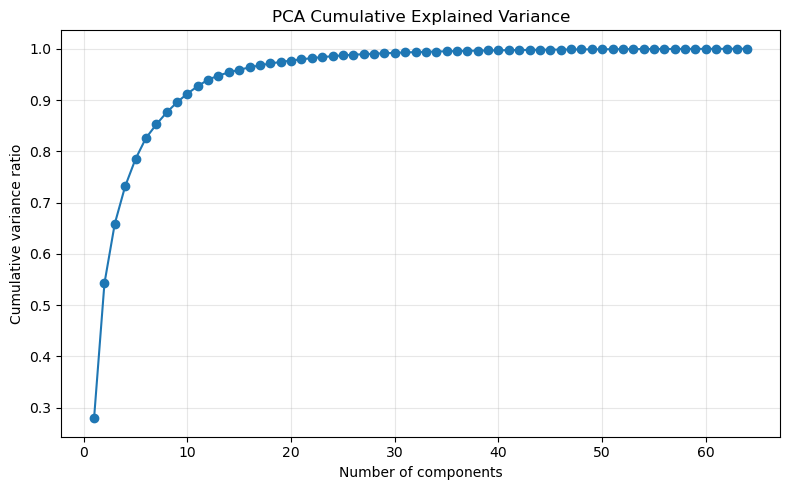

PCA(2) explained variance ratio: [0.27907166 0.26318952]
PCA(2) cumulative explained variance: 0.5423


In [14]:
# PCA explained variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_comp = min(N_PCA_COMPONENTS, X_scaled.shape[1], X_scaled.shape[0])
pca_full = PCA(n_components=n_comp, random_state=SEED)
pca_full.fit(X_scaled)

cum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum) + 1), cum, marker="o")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance ratio")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X_scaled)
print(f"PCA(2) explained variance ratio: {pca2.explained_variance_ratio_}")
print(f"PCA(2) cumulative explained variance: {pca2.explained_variance_ratio_.sum():.4f}")


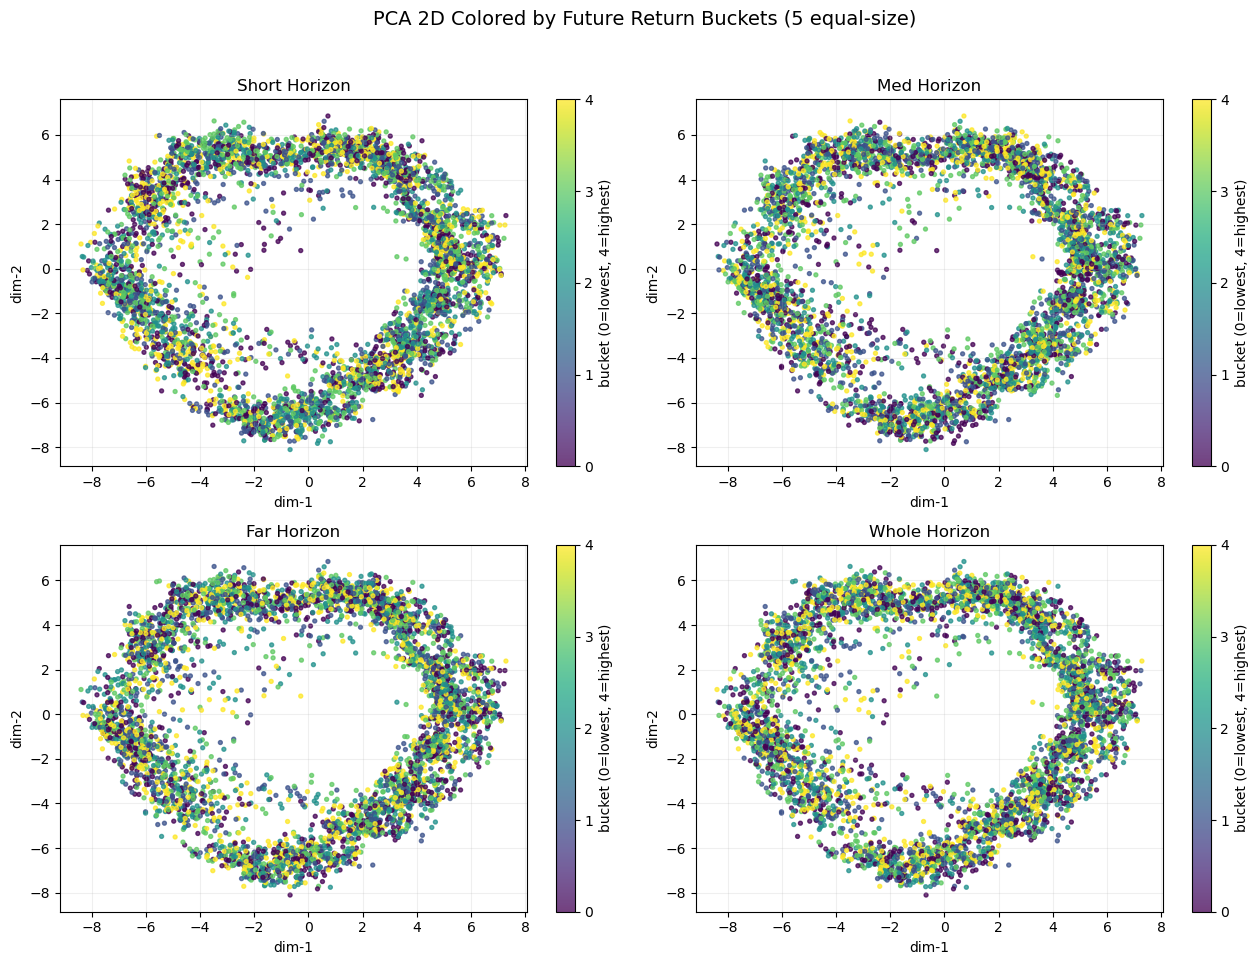

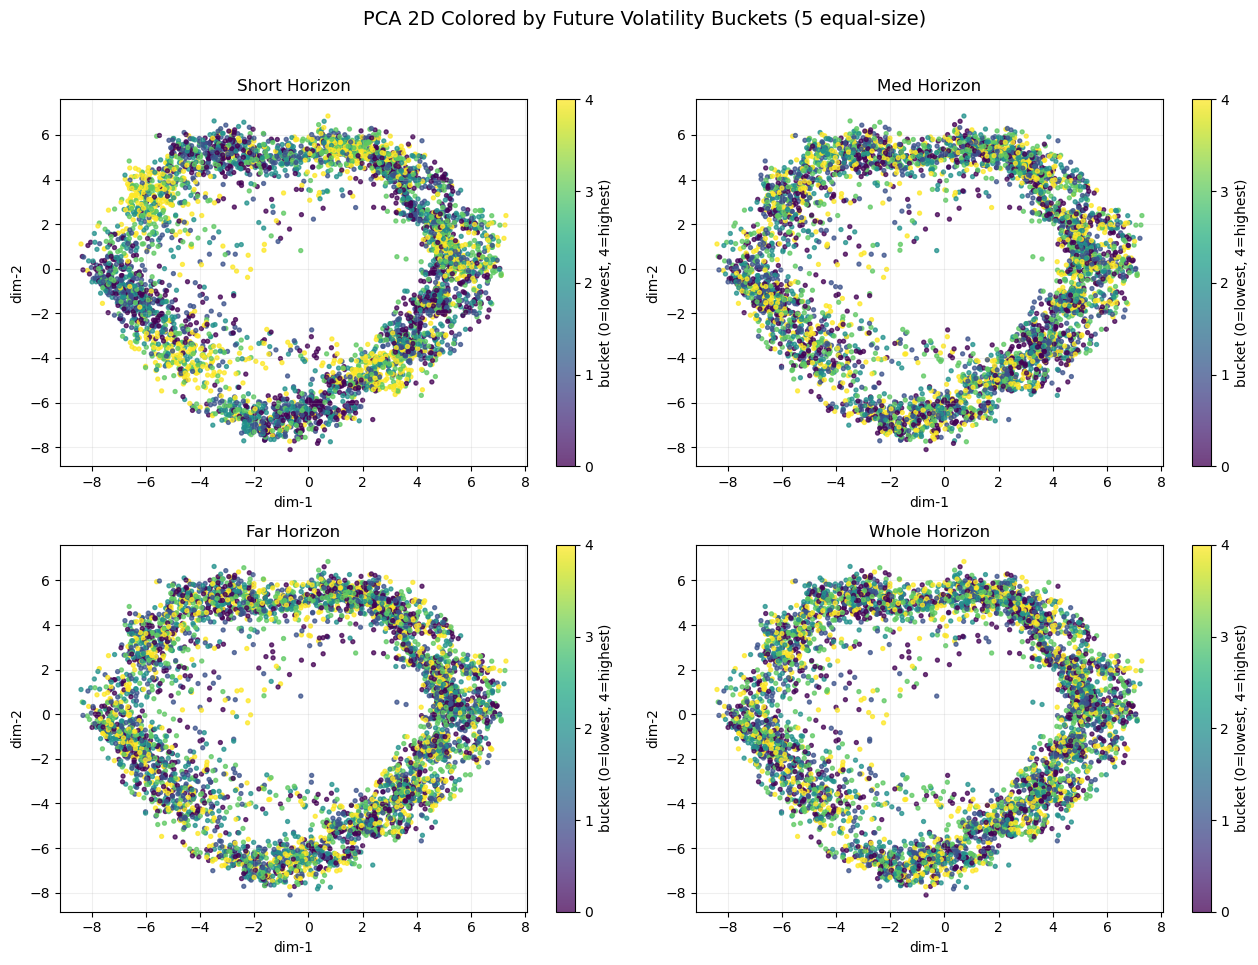

In [15]:
# PCA 2D: return buckets and volatility buckets (5 equal-size buckets)

def equal_size_bucket_ids(values: np.ndarray, n_bins: int = 5) -> np.ndarray:
    v = np.asarray(values, dtype=np.float64).copy()
    if np.any(~np.isfinite(v)):
        med = np.nanmedian(v)
        v[~np.isfinite(v)] = med if np.isfinite(med) else 0.0
    n = len(v)
    order = np.argsort(v)
    buckets = np.empty(n, dtype=np.int64)
    for rank, idx in enumerate(order):
        buckets[idx] = min(n_bins - 1, (rank * n_bins) // max(n, 1))
    return buckets


def plot_horizon_panels(coords2d: np.ndarray, metric_dict: dict[str, np.ndarray], title_prefix: str):
    horizons = [("short", "Short"), ("med", "Med"), ("far", "Far"), ("whole", "Whole")]
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()

    for ax, (key, name) in zip(axes, horizons):
        vals = np.asarray(metric_dict[key], dtype=np.float64)
        buckets = equal_size_bucket_ids(vals, n_bins=5)

        sc = ax.scatter(
            coords2d[:, 0],
            coords2d[:, 1],
            c=buckets,
            s=8,
            alpha=0.75,
            cmap="viridis",
            vmin=0,
            vmax=4,
        )
        ax.set_title(f"{name} Horizon")
        ax.set_xlabel("dim-1")
        ax.set_ylabel("dim-2")
        ax.grid(True, alpha=0.2)
        cb = plt.colorbar(sc, ax=ax)
        cb.set_ticks([0, 1, 2, 3, 4])
        cb.set_label("bucket (0=lowest, 4=highest)")

    fig.suptitle(title_prefix, fontsize=14)
    fig.tight_layout(rect=[0, 0.02, 1, 0.96])
    plt.show()


plot_horizon_panels(X_pca2, horizon_returns, "PCA 2D Colored by Future Return Buckets (5 equal-size)")
plot_horizon_panels(X_pca2, horizon_vols, "PCA 2D Colored by Future Volatility Buckets (5 equal-size)")


Running t-SNE with n=2000, perplexity=30


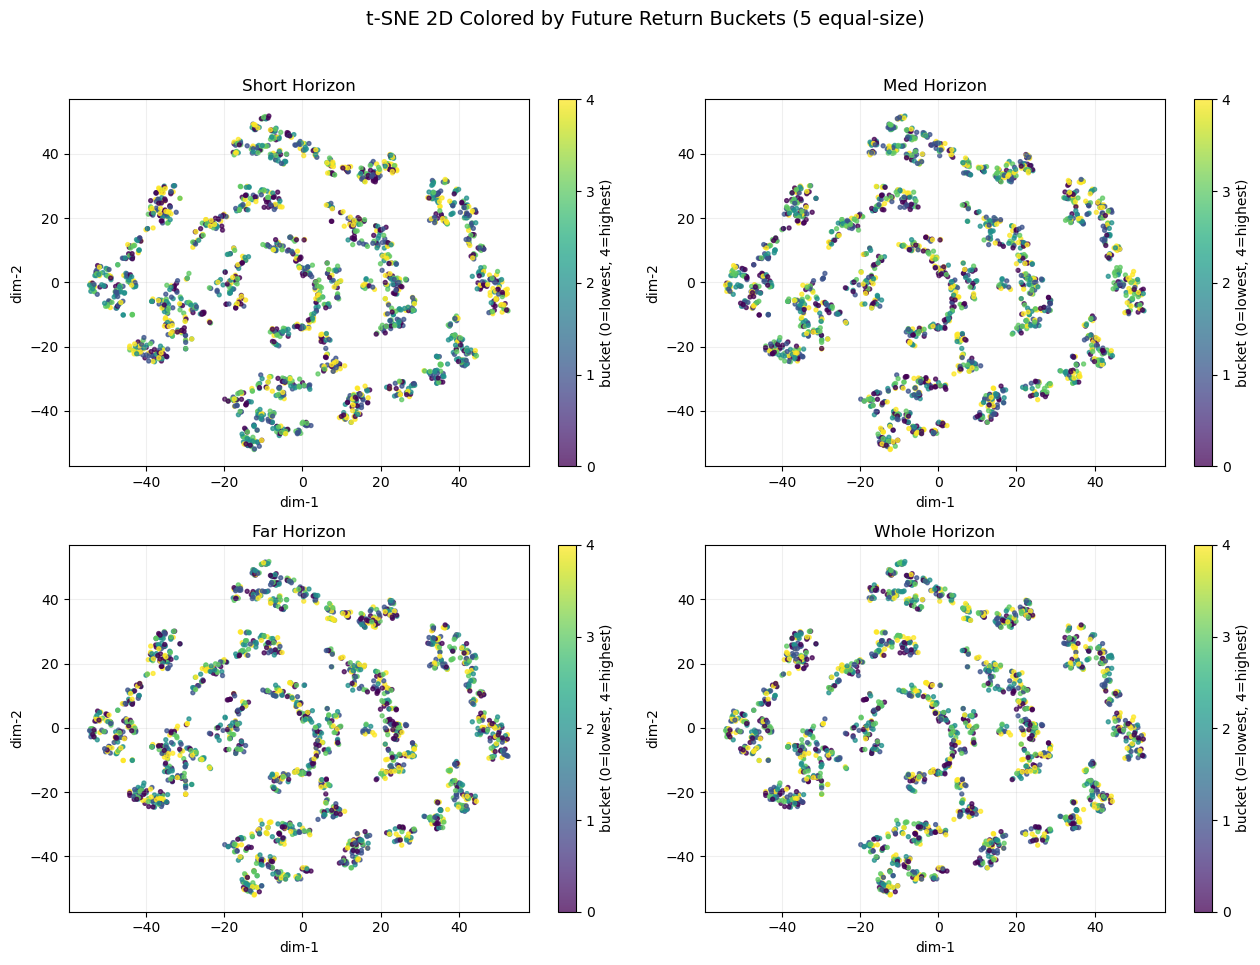

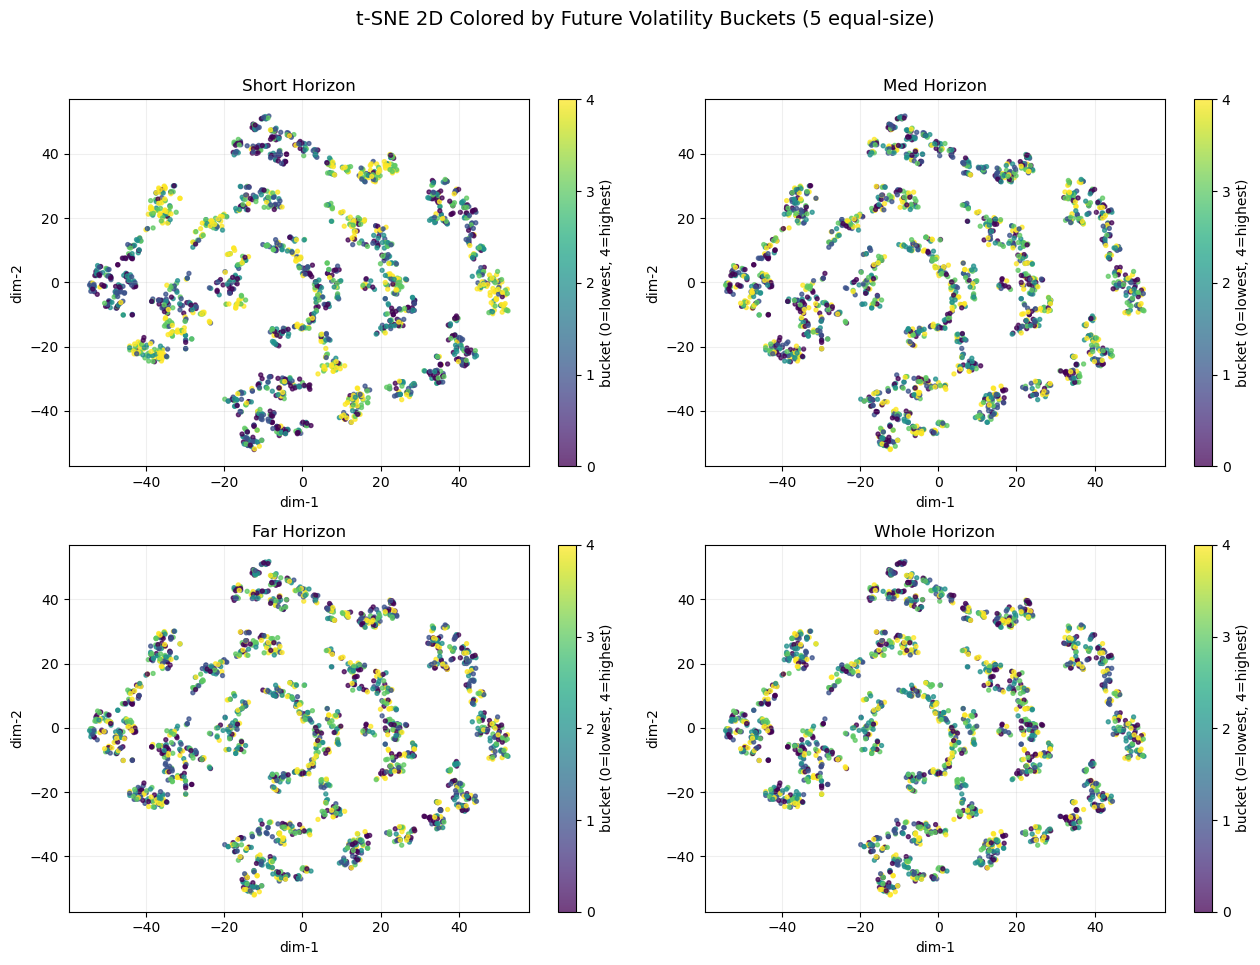

In [16]:
# t-SNE 2D: same 8 horizon bucket plots (returns + vols)
n_tsne = min(TSNE_MAX_POINTS, X_scaled.shape[0])
idx = np.random.choice(np.arange(X_scaled.shape[0]), size=n_tsne, replace=False)

X_tsne_input = X_scaled[idx]
returns_tsne = {k: np.asarray(v)[idx] for k, v in horizon_returns.items()}
vols_tsne = {k: np.asarray(v)[idx] for k, v in horizon_vols.items()}

perplexity = min(TSNE_PERPLEXITY, max(5, (n_tsne - 1) // 3))
print(f"Running t-SNE with n={n_tsne}, perplexity={perplexity}")

import inspect

tsne_kwargs = dict(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=SEED,
)
if "max_iter" in inspect.signature(TSNE).parameters:
    tsne_kwargs["max_iter"] = 1000
else:
    tsne_kwargs["n_iter"] = 1000

tsne = TSNE(**tsne_kwargs)
X_tsne2 = tsne.fit_transform(X_tsne_input)


def equal_size_bucket_ids(values: np.ndarray, n_bins: int = 5) -> np.ndarray:
    v = np.asarray(values, dtype=np.float64).copy()
    if np.any(~np.isfinite(v)):
        med = np.nanmedian(v)
        v[~np.isfinite(v)] = med if np.isfinite(med) else 0.0
    n = len(v)
    order = np.argsort(v)
    buckets = np.empty(n, dtype=np.int64)
    for rank, idx2 in enumerate(order):
        buckets[idx2] = min(n_bins - 1, (rank * n_bins) // max(n, 1))
    return buckets


def plot_horizon_panels(coords2d: np.ndarray, metric_dict: dict[str, np.ndarray], title_prefix: str):
    horizons = [("short", "Short"), ("med", "Med"), ("far", "Far"), ("whole", "Whole")]
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()

    for ax, (key, name) in zip(axes, horizons):
        vals = np.asarray(metric_dict[key], dtype=np.float64)
        buckets = equal_size_bucket_ids(vals, n_bins=5)

        sc = ax.scatter(
            coords2d[:, 0],
            coords2d[:, 1],
            c=buckets,
            s=8,
            alpha=0.75,
            cmap="viridis",
            vmin=0,
            vmax=4,
        )
        ax.set_title(f"{name} Horizon")
        ax.set_xlabel("dim-1")
        ax.set_ylabel("dim-2")
        ax.grid(True, alpha=0.2)
        cb = plt.colorbar(sc, ax=ax)
        cb.set_ticks([0, 1, 2, 3, 4])
        cb.set_label("bucket (0=lowest, 4=highest)")

    fig.suptitle(title_prefix, fontsize=14)
    fig.tight_layout(rect=[0, 0.02, 1, 0.96])
    plt.show()


plot_horizon_panels(X_tsne2, returns_tsne, "t-SNE 2D Colored by Future Return Buckets (5 equal-size)")
plot_horizon_panels(X_tsne2, vols_tsne, "t-SNE 2D Colored by Future Volatility Buckets (5 equal-size)")


embedding dims: 64
std mean=0.191180, min=0.090693, max=0.358591


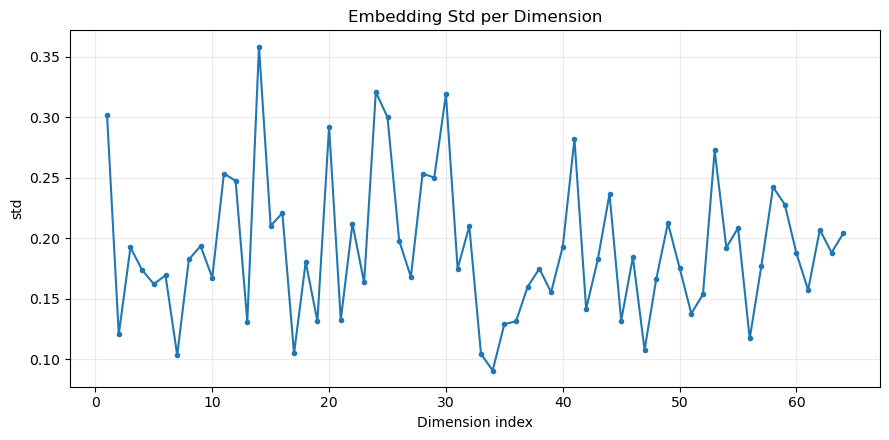

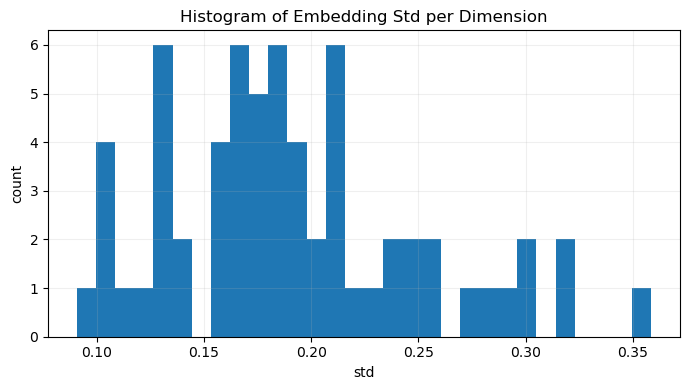

In [17]:
# Std per dimension
std_per_dim = X.std(axis=0)

print(f"embedding dims: {X.shape[1]}")
print(f"std mean={std_per_dim.mean():.6f}, min={std_per_dim.min():.6f}, max={std_per_dim.max():.6f}")

plt.figure(figsize=(9, 4.5))
plt.plot(np.arange(1, len(std_per_dim) + 1), std_per_dim, marker="o", markersize=3)
plt.title("Embedding Std per Dimension")
plt.xlabel("Dimension index")
plt.ylabel("std")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(std_per_dim, bins=30)
plt.title("Histogram of Embedding Std per Dimension")
plt.xlabel("std")
plt.ylabel("count")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
